<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_18_75_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.6/566.6 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 641.2/641.2 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.3/661.3 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pymatgen.core import Structure
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [ ]:
# The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.986574  0.002021  0.99113
  1  Cu    0.999292  0.49181   0.512203
  2  Cu    0.50948   0.0169    0.487324
  3  Cu    0.500727  0.505707  0.006671
  4  Ni    0.2569    0.742961  0.724781
  5  Ni    0.252551  0.23115   0.751468
  6  Ni    0.248821  0.244621  0.246916
  7  Ni    0.24948   0.749233  0.251069
  8  Ni    0.760563  0.720485  0.241378
  9  Ni    0.751595  0.250109  0.246709
 10  Ni    0.744667  0.245004  0.770129
 11  Ni    0.746419  0.730937  0.739451
 12  Sn    0.00338   0.006623  0.494684
 13  Sn    0.013633  0.501239  0.996636
 14  Sn    0.515108  0.996362  0.004528
 15  Sn    0.507486  0.487842  0.501704


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : np.float64(6.349516720528679) np.float64(0.0) np.float64(3.887957663964023e-16)
      B : np.float64(1.0210801652782683e-15) np.float64(6.349516720528679) np.float64(3.887957663964023e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(6.349516720528679)
    pbc : True True True
PeriodicSite: Cu0 (Cu) (6.264, 0.01283, 6.293) [0.9866, 0.002021, 0.9911]
PeriodicSite: Cu1 (Cu) (6.345, 3.123, 3.252) [0.9993, 0.4918, 0.5122]
PeriodicSite: Cu2 (Cu) (3.235, 0.1073, 3.094) [0.5095, 0.0169, 0.4873]
PeriodicSite: Cu3 (Cu) (3.179, 3.211, 0.04236) [0.5007, 0.5057, 0.006671]
PeriodicSite: Ni4 (Ni) (1.631, 4.717, 4.602) [0.2569, 0.743, 0.7248]
PeriodicSite: Ni5 (Ni) (1.604, 1.468, 4.771) [0.2526, 0.2311, 0.7515]
PeriodicSite: Ni6 (Ni) (1.58, 1.553, 1.568) [0.2488, 0.2446, 0.2469]
PeriodicSite: Ni7 (Ni) (1.584, 4.757, 1.594) [0.2495, 0.7492, 0

In [ ]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[<UNIVERSAL_CALCULATORS.CHGNet: 'CHGNet'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-PBE-2025.2.10: 'CHGNet-PES-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-r2SCAN-2025.2.10: 'CHGNet-PES-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DeePMD: 'DeePMD'>,
 <UNIVERSAL_CALCULATORS.FAIRChem: 'FAIRChem'>,
 <UNIVERSAL_CALCULATORS.GRACE: 'GRACE'>,
 <UNIVERSAL_CALCULATORS.M3GNet: 'M3GNet'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-PBE-2025.2: 'M3GNet-PES-MatPES-PBE-2025.2'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-r2SCAN-2025.2: 'M3GNet-PES-MatPES-r2SCAN-2025.2'>,
 <UNIVERSAL_CALCULATORS.MACE: 'MACE'>,
 <UNIVERSAL_CALCULATORS.MatterSim: 'MatterSim'>,
 <UNIVERSAL_CALCULATORS.ORB: 'ORB'>,
 <UNIVERSAL_CALCULATORS.PBE: 'PBE'>,
 <UNIVERSAL_CALCULATORS.PETMAD: 'PETMAD'>,
 <UNIVERSAL_CALCULATORS.QET-PES-MatQ: 'QET-PES-MatQ'>,
 <UNIVERSAL_CALCULATORS.SevenNet: 'SevenNet'>,
 <UNIVERSAL_CALCULATORS.TensorNet: 'TensorNet'>,
 <UNIVERSAL_CALCULATORS.TensorNet-PES-MatPES-PBE-2025.2

In [ ]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list all "aliased" models

{'chgnet': 'CHGNet-PES-MatPES-PBE-2025.1',
 'm3gnet': 'M3GNet-PES-MatPES-PBE-2025.1',
 'pbe': 'TensorNet-PES-MatPES-PBE-2025.2',
 'r2scan': 'TensorNet-PES-MatPES-r2SCAN-2025.2',
 'tensornet': 'TensorNet-PES-MatPES-PBE-2025.2'}


In [ ]:
calculator_pbe = matcalc.load_fp("pbe")
# calculator_pbe = matcalc.load_fp("TensorNet-MatPES-PBE-v2025.1-PES")

model.pt:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

state.pt:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

model.json: 0.00B [00:00, ?B/s]

In [ ]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...


/usr/local/lib/python3.12/dist-packages/matgl/graph/_converters_pyg.py:75: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  lattice = torch.as_tensor(lattice_matrix, dtype=matgl.float_th, device=device)


Optimization Successful!
Final Energy: -75.9401 eV
Final Optimized Volume: 213.29 A^3


In [ ]:
pprint.pprint(data)

{'a': 5.9749864529239,
 'alpha': 89.9892907866118,
 'b': 5.974985337952056,
 'beta': 90.0246508592631,
 'c': 5.974312540249984,
 'energy': -75.94013214111328,
 'final_structure': Structure Summary
Lattice
    abc : 5.9749864529239 5.974985337952056 5.974312540249984
 angles : 89.9892907866118 90.0246508592631 90.01545527745544
 volume : 213.28565344517185
      A : np.float64(5.9749862603507) np.float64(-0.0008058304232197644) np.float64(-0.0012852555474947708)
      B : np.float64(-0.000805774914103578) np.float64(5.9749852575292275) np.float64(0.0005583701490422951)
      C : np.float64(-0.0012851943391362446) np.float64(0.0005581843562071635) np.float64(5.974312375938669)
    pbc : True True True
PeriodicSite: Cu (5.988, -0.06496, 5.961) [1.002, -0.01083, 0.998]
PeriodicSite: Cu (6.011, 2.925, 2.995) [1.006, 0.4896, 0.5015]
PeriodicSite: Cu (3.042, -0.01543, 2.949) [0.5093, -0.002559, 0.4938]
PeriodicSite: Cu (2.963, 2.981, -0.01363) [0.496, 0.4989, -0.002221]
PeriodicSite: Ni (1.53

In [ ]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.974986   5.974985   5.974313
angles:  89.989291  90.024651  90.015455
pbc   :       True       True       True
Sites (16)
  #  SP            a          b          c
---  ----  ---------  ---------  ---------
  0  Cu     1.00234   -0.01083    0.998031
  1  Cu     1.0062     0.489581   0.501455
  2  Cu     0.50931   -0.002559   0.49379
  3  Cu     0.495951   0.498939  -0.002221
  4  Ni     0.256392   0.75505    0.739795
  5  Ni     0.257819   0.236622   0.750867
  6  Ni     0.248465   0.24029    0.243948
  7  Ni     0.247316   0.748017   0.25878
  8  Ni     0.756796   0.73803    0.252175
  9  Ni     0.75746    0.254313   0.236866
 10  Ni     0.748072   0.249005   0.755153
 11  Ni     0.748595   0.742574   0.745887
 12  Sn    -0.005028   0.00201    0.500174
 13  Sn     0.010237   0.501159   0.991544
 14  Sn     0.506356   0.990472   0.00461
 15  Sn     0.500394   0.490332   0.495926


Structure Summary
Lattice
    abc : 5.9749864529239 5.974985337952056 5.974312540249984
 angles : 89.9892907866118 90.0246508592631 90.01545527745544
 volume : 213.28565344517185
      A : np.float64(5.9749862603507) np.float64(-0.0008058304232197644) np.float64(-0.0012852555474947708)
      B : np.float64(-0.000805774914103578) np.float64(5.9749852575292275) np.float64(0.0005583701490422951)
      C : np.float64(-0.0012851943391362446) np.float64(0.0005581843562071635) np.float64(5.974312375938669)
    pbc : True True True
PeriodicSite: Cu (5.988, -0.06496, 5.961) [1.002, -0.01083, 0.998]
PeriodicSite: Cu (6.011, 2.925, 2.995) [1.006, 0.4896, 0.5015]
PeriodicSite: Cu (3.042, -0.01543, 2.949) [0.5093, -0.002559, 0.4938]
PeriodicSite: Cu (2.963, 2.981, -0.01363) [0.496, 0.4989, -0.002221]
PeriodicSite: Ni (1.53, 4.512, 4.42) [0.2564, 0.755, 0.7398]
PeriodicSite: Ni (1.539, 1.414, 4.486) [0.2578, 0.2366, 0.7509]
PeriodicSite: Ni (1.484, 1.436, 1.457) [0.2485, 0.2403, 0.2439]
PeriodicSite

In [ ]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe' generated
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 144.94 GPa
Shear Modulus: 38.22 GPa


Calculating Phonon Data for Pure CuNi2Sn...


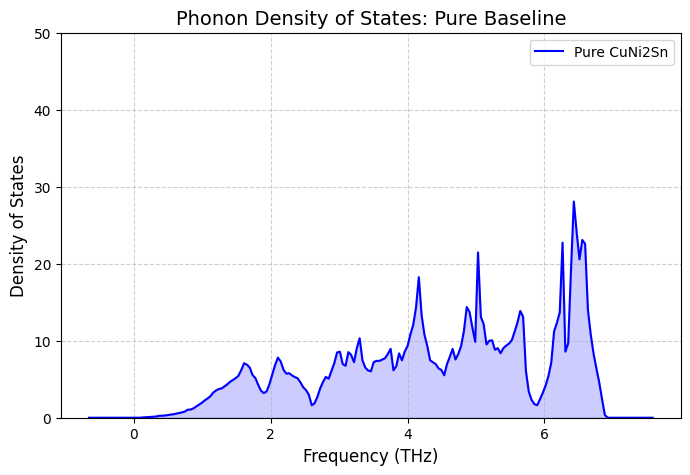

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization for Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 1. Start with a fresh copy of your pure optimized CuNi2Sn structure
sac_al_18_75 = final_structure_pbe.copy()

# 2. Replace THREE sites with Al to reach 18.75% concentration
# We use indices 12 (Sn), 0 (Cu), and 4 (Ni) to keep the Al atoms separated
sac_al_18_75.replace(12, "Al")
sac_al_18_75.replace(0, "Al")
sac_al_18_75.replace(4, "Al")

print(f"Created 18.75% Al-doped structure: {sac_al_18_75.formula}")

# 3. High-Precision Relaxation
# We use the global relax_calc with fmax=0.001 for publication consistency
print("Starting high-precision optimization for 18.75% Al...")
relax_results_18_75 = relax_calc.calc(sac_al_18_75)
opt_struct_18_75 = relax_results_18_75["final_structure"]

print(f"18.75% Optimized Energy: {relax_results_18_75['energy']:.4f} eV")

Created 18.75% Al-doped structure: Al3 Cu3 Ni7 Sn3
Starting high-precision optimization for 18.75% Al...
18.75% Optimized Energy: -75.3003 eV


In [ ]:
# 4. Calculate Elastic Moduli for the new concentration
elastic_results_18_75 = elastic_calc.calc(opt_struct_18_75)
multiplier_GPa = 160.2176621

bulk_18_75 = elastic_results_18_75['bulk_modulus_vrh'] * multiplier_GPa
shear_18_75 = elastic_results_18_75['shear_modulus_vrh'] * multiplier_GPa

print(f"--- 18.75% Al Doping Results ---")
print(f"Bulk Modulus: {bulk_18_75:.2f} GPa")
print(f"Shear Modulus: {shear_18_75:.2f} GPa")

# Monitor Pugh's Ratio for the brittleness argument
print(f"Pugh's Ratio (G/B): {shear_18_75 / bulk_18_75:.3f}")

--- 18.75% Al Doping Results ---
Bulk Modulus: 126.83 GPa
Shear Modulus: 40.16 GPa
Pugh's Ratio (G/B): 0.317


Calculating Phonon Data for 18.75% Al-Doped CuNi2Sn...


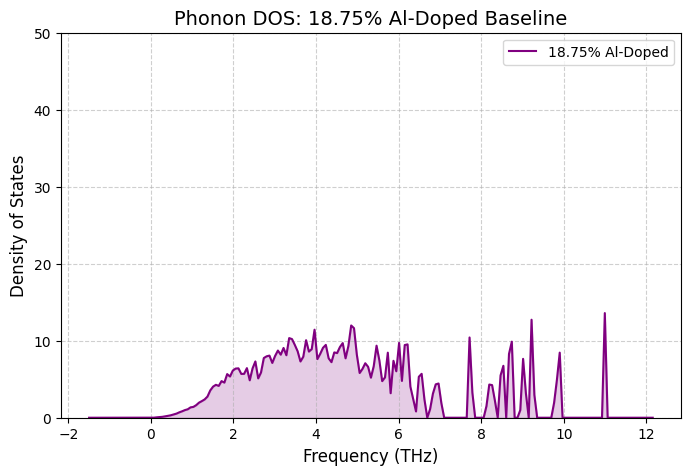

In [ ]:
# 5. Initialize Phonon Calculator (2x2x2 supercell)
phonon_calc_18_75 = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for 18.75% Al-Doped CuNi2Sn...")
phonon_data_18_75 = phonon_calc_18_75.calc(opt_struct_18_75)
ph_18_75 = phonon_data_18_75["phonon"]

# Run DOS with high-mesh resolution
ph_18_75.run_mesh([20, 20, 20])
ph_18_75.run_total_dos()
dos_18_75 = ph_18_75.get_total_dos_dict()

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(dos_18_75['frequency_points'], dos_18_75['total_dos'], color='purple', label='18.75% Al-Doped')
plt.fill_between(dos_18_75['frequency_points'], dos_18_75['total_dos'], color='purple', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon DOS: 18.75% Al-Doped Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import numpy as np

# Extract Thermodynamic Stability for 18.75% Al at Harsh Environment (473K)
ph_18_75.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_18_75 = ph_18_75.get_thermal_properties_dict()

# Use np to find the index closest to your target temperature (473K)
idx_473 = (np.abs(tp_18_75['temperatures'] - 473)).argmin()

print(f"--- 18.75% Al THERMODYNAMICS ---")
print(f"Free Energy at 473K: {tp_18_75['free_energy'][idx_473]:.4f} kJ/mol")
print(f"Entropy at 473K: {tp_18_75['entropy'][idx_473]:.4f} J/K/mol")

--- 18.75% Al THERMODYNAMICS ---
Free Energy at 473K: -156.3125 kJ/mol
Entropy at 473K: 737.9414 J/K/mol
